**Этапы исследования:**

1. загрузка данных, обрезка дорожного графа по маске
2. привязка объектов к ближайшему узлу дорожного графа
3. формирование матрицы расстояний для каждой пары пункт спроса - пункт обслуживания
4. каждому пункту спроса назначается вес (численность населения)
5. реализация алгоритма
6. расчет доли населения, обеспеченная пунктами обслуживания

In [3]:
#имортируем библиотеки
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from spopt.locate import MCLP
import pulp

In [4]:
#загрузим векторные слои
houses = gpd.read_file('/content/drive/MyDrive/Диплом/people_kalininskyi.gpkg')

In [5]:
warehouses = gpd.read_file('/content/drive/MyDrive/Диплом/kp_kalininskyi.gpkg')

In [6]:
mask = gpd.read_file('/content/drive/MyDrive/Диплом/mask_spb.gpkg')

In [7]:
cost_df = pd.read_excel('/content/drive/MyDrive/Диплом/kp_cost_matrix.xlsx')

In [8]:
mask = mask.to_crs(epsg=4326)
polygon = mask.geometry.unary_union

/tmp/ipykernel_2217/3386858467.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = mask.geometry.unary_union


In [9]:
#загрузим дорожный граф по маске
G = ox.graph_from_polygon(
    polygon,
    network_type="drive",
    simplify=True
)

In [10]:
#приведем к одной системе координат
G = ox.project_graph(G)
houses = houses.to_crs(G.graph["crs"])
warehouses = warehouses.to_crs(G.graph["crs"])

In [11]:
#возьмем ближайшие узлы графа
houses["node"] = ox.distance.nearest_nodes(
    G,
    X=houses.geometry.x,
    Y=houses.geometry.y
)

warehouses["node"] = ox.distance.nearest_nodes(
    G,
    X=warehouses.geometry.x,
    Y=warehouses.geometry.y
)

In [12]:
#посчитаем матрицу расстояний
client_nodes = houses["node"].values
facility_nodes = warehouses["node"].values

n_clients = len(client_nodes)
n_facilities = len(facility_nodes)

cost_matrix = np.zeros((n_clients, n_facilities))

In [13]:
#рассчитаем кратчайшие пути методом дейкстра
for i, c_node in enumerate(client_nodes):
    lengths = nx.single_source_dijkstra_path_length(G, c_node, weight="length")

    for j, f_node in enumerate(facility_nodes):
        cost_matrix[i, j] = lengths.get(f_node, np.inf)

In [14]:
cost_pivot = cost_df.pivot_table(
    index='household_id',
    columns='kp_id',
    values='distance_m'
)

In [15]:
warehouses['id'] = warehouses['id'].astype(int)
cost_df['kp_id'] = cost_df['kp_id'].astype(int)

In [16]:
cost_pivot = cost_pivot.loc[houses['household_id']]
cost_pivot = cost_pivot[warehouses['id']]

In [17]:
cost_matrix = cost_pivot.values

In [18]:
cost_matrix = np.where(np.isnan(cost_matrix), np.inf, cost_matrix)

In [19]:
#зададим веса
ai = houses["pop2025"].fillna(1).values

In [20]:
#запустим модель

SERVICE_RADIUS = 1000
P_FACILITIES = 356

solver = pulp.PULP_CBC_CMD(msg=False)

model = MCLP.from_cost_matrix(
    cost_matrix,
    ai,
    SERVICE_RADIUS,
    p_facilities=P_FACILITIES,
    name="mclp-osm-network"
)

model = model.solve(solver)

print(f"Coverage: {model.perc_cov}%")

Coverage: 99.61389961389962%


In [21]:
warehouses["selected"] = [v.varValue for v in model.fac_vars]
selected_warehouses = warehouses[warehouses["selected"] == 1]

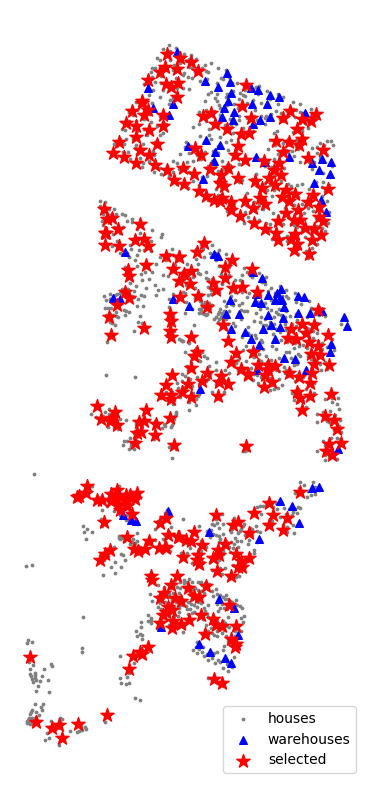

In [22]:
#визуализация
fig, ax = plt.subplots(figsize=(10, 10))

houses.plot(
    ax=ax,
    color="gray",
    markersize=3,
    label="houses"
)

warehouses[warehouses["selected"] == 0].plot(
    ax=ax,
    color="blue",
    markersize=30,
    marker="^",
    label="warehouses"
)
warehouses[warehouses["selected"] == 1].plot(
    ax=ax,
    color="red",
    markersize=100,
    marker="*",
    label="selected"
)

plt.legend()
plt.axis("off")
plt.show()

In [23]:
selected_idx = np.where(warehouses["selected"] == 1)[0]
selected_costs = cost_matrix[:, selected_idx]
nearest_selected_idx = selected_costs.argmin(axis=1)
nearest_facility_idx = selected_idx[nearest_selected_idx]
houses["nearest_warehouse_idx"] = nearest_facility_idx
houses["kp_num"] = warehouses.iloc[nearest_facility_idx]["kp_num"].values
result = houses[["OBJECTID_1", "kp_num"]]

#сохраним
result.to_csv("/content/drive/MyDrive/Диплом/mlcp_kalininskiy1.csv", index=False)